# Customer Churn Prediction — A Comparative Classifier Study

**Task:** Predict whether a telecom customer will churn (binary classification) from the IBM **Telco Customer Churn** dataset (7,043 customers, 20 features).

**Goal of this notebook:** run the full data-mining pipeline and *compare five classifiers* — Decision Tree, Gaussian Naïve Bayes, k-Nearest Neighbors, Random Forest, and XGBoost — then study how class-imbalance handling changes the precision/recall trade-off.

**Outline**
1. Data loading & cleaning
2. Exploratory data analysis (EDA)
3. Preprocessing & train/test split
4. Model training & hyperparameter tuning
5. Evaluation & model comparison
6. Feature importance & SHAP interpretation
7. Class-imbalance study (baseline vs. SMOTE vs. class weighting)
8. Discussion & conclusions

All heavy lifting is factored into the reusable `src/` package; this notebook is the narrative that calls it. Every random seed is fixed to `42`.

In [1]:
import sys
from pathlib import Path

# Make the repo root importable whether the notebook is launched from the
# repo root or from the notebooks/ folder.
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from src.data_loader import load_clean, TARGET
from src.preprocessing import (
    split_feature_types, build_preprocessor, make_split, RANDOM_STATE,
)
from src.models import get_model_zoo, build_pipeline, build_imbalanced_pipeline
from src import evaluate as ev

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
# Reproducibility is handled explicitly via random_state=RANDOM_STATE on every
# estimator, the split, and SMOTE, so no global RNG seeding is needed.
print('Setup complete. Repo root:', ROOT)

Setup complete. Repo root: c:\Users\mehmet\Desktop\bil476\churn-classifier-benchmark


## 1. Data loading & cleaning

The raw file is loaded and lightly cleaned by `src.data_loader.load_clean()`:

* `customerID` is dropped (unique identifier, no predictive value).
* `TotalCharges` is stored as text with ~11 blank entries for brand-new customers (`tenure == 0`); it is coerced to numeric so the blanks become `NaN` (imputed later, inside cross-validation).
* `SeniorCitizen` (0/1) is mapped to `No`/`Yes` so it is treated like the other binary flags.
* The target `Churn` is mapped `Yes/No → 1/0`.

Crucially, *no* imputation/encoding/scaling happens here — that is deferred to the modeling pipeline to avoid data leakage.

In [2]:
df = load_clean()
print('Shape:', df.shape)
df.head()

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# Structure, dtypes, and missing values
df.info()
print('\nMissing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])
print('\nChurn rate: {:.1%}'.format(df[TARGET].mean()))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [4]:
# Descriptive statistics for numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.000,1.0000,1.00


## 2. Exploratory Data Analysis

We look at (a) the class balance of the target, (b) how the numeric features relate to churn, (c) churn rates across categorical features, and (d) correlations. Figures are saved to `figures/` for the report.

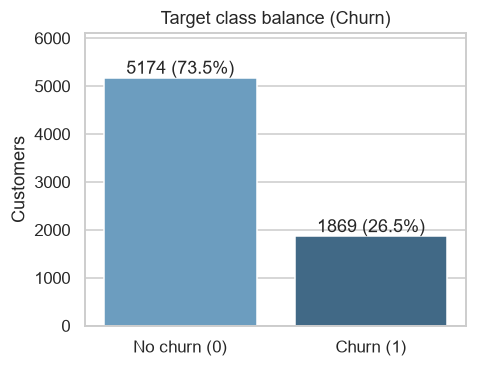

In [5]:
# (a) Target class balance
counts = df[TARGET].value_counts().sort_index()
labels = ['No churn (0)', 'Churn (1)']
fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.barplot(x=labels, y=counts.values, hue=labels, palette='Blues_d', legend=False, ax=ax)
ax.set_ylim(0, counts.values.max() * 1.18)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v} ({v / len(df):.1%})', ha='center', va='bottom')
ax.set_ylabel('Customers')
ax.set_title('Target class balance (Churn)')
fig.tight_layout()
fig.savefig(ROOT / 'figures' / 'target_balance.png', dpi=150)
plt.show()

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


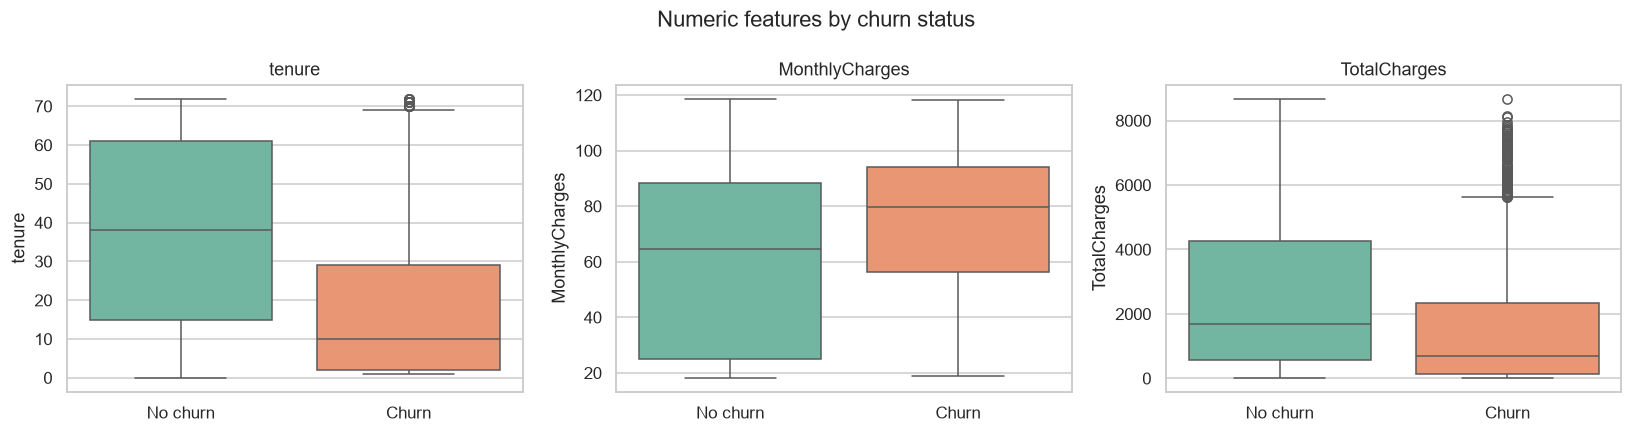

In [6]:
# (b) Numeric features vs churn
numeric, categorical = split_feature_types(df)
print('Numeric:', numeric)
print('Categorical:', categorical)

fig, axes = plt.subplots(1, len(numeric), figsize=(5 * len(numeric), 4))
for ax, col in zip(np.atleast_1d(axes), numeric):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, palette='Set2', legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No churn', 'Churn'])
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Numeric features by churn status')
fig.tight_layout()
fig.savefig(ROOT / 'figures' / 'numeric_by_churn.png', dpi=150)
plt.show()

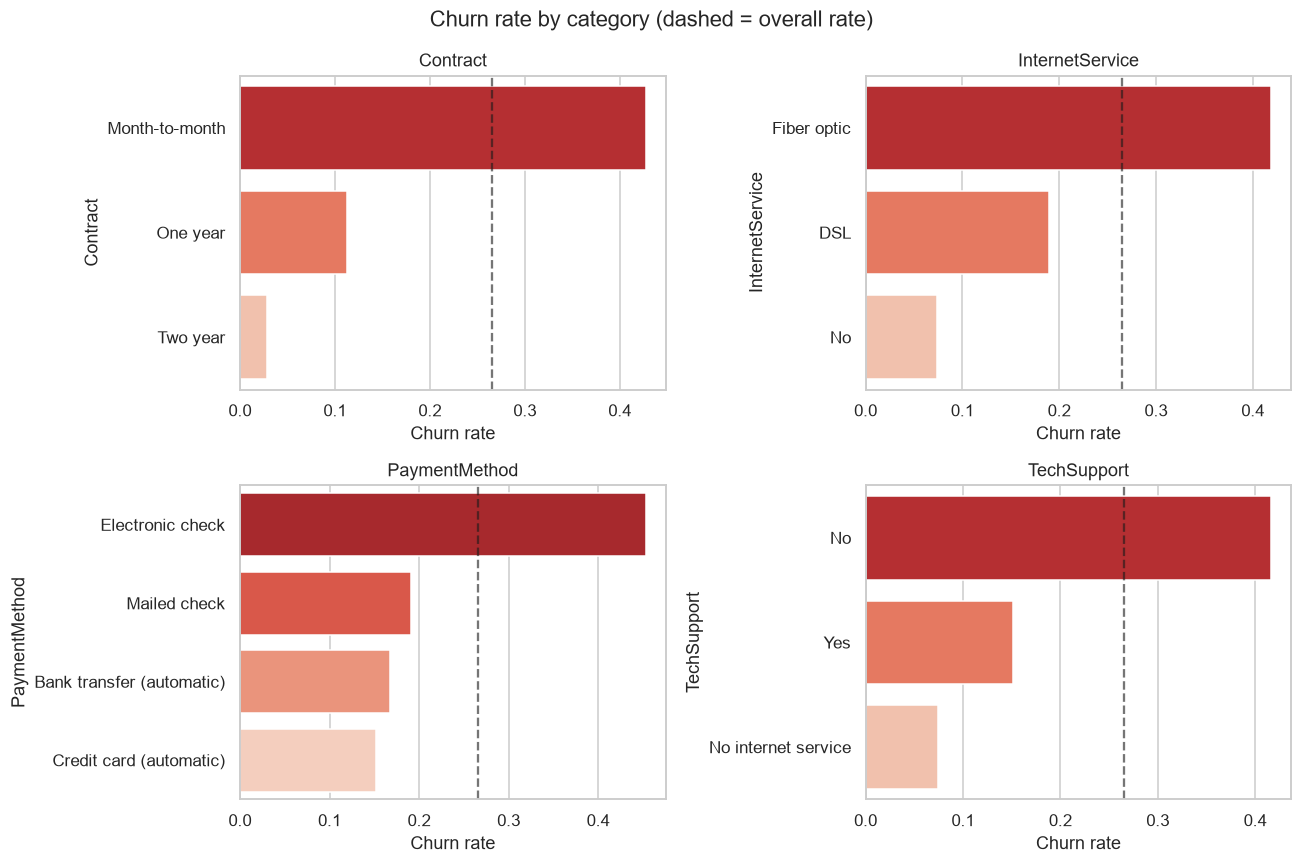

In [7]:
# (c) Churn rate across the most informative categorical features
focus = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
focus = [c for c in focus if c in categorical]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), focus):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, palette='Reds_r', legend=False, ax=ax)
    ax.set_xlabel('Churn rate')
    ax.set_title(col)
    ax.axvline(df[TARGET].mean(), ls='--', color='k', alpha=0.6)
fig.suptitle('Churn rate by category (dashed = overall rate)')
fig.tight_layout()
fig.savefig(ROOT / 'figures' / 'categorical_churn_rates.png', dpi=150)
plt.show()

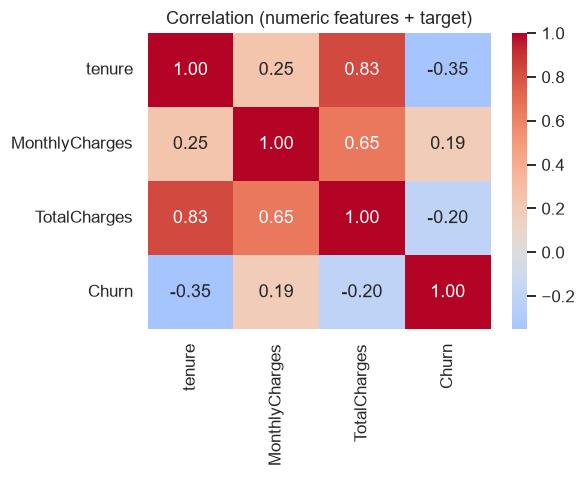

In [8]:
# (d) Correlation among numeric features and the target
corr = df[numeric + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation (numeric features + target)')
fig.tight_layout()
fig.savefig(ROOT / 'figures' / 'correlation_heatmap.png', dpi=150)
plt.show()

**EDA observations:**

- The target is imbalanced (~27% churn), so accuracy alone is misleading — we will emphasize F1, recall, and ROC/PR-AUC.
- `tenure` is strongly (negatively) associated with churn: new customers churn far more.
- Month-to-month `Contract`, `Fiber optic` internet, and `Electronic check` payment stand out as high-churn segments.
- `MonthlyCharges` and `TotalCharges` are correlated (both tied to tenure), a redundancy the models must cope with.

## 3. Preprocessing & train/test split

We use a **stratified 80/20 split** (preserving the churn rate) and a shared `ColumnTransformer`:

* numeric → median imputation + standardization,
* categorical → most-frequent imputation + one-hot encoding.

The transformer is wrapped inside each model's `Pipeline`, so it is re-fit on the training fold only during cross-validation — no leakage.

In [9]:
X_train, X_test, y_train, y_test = make_split(df)
preprocessor = build_preprocessor(numeric, categorical)
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Train churn rate: {:.1%} | Test churn rate: {:.1%}'.format(y_train.mean(), y_test.mean()))

Train: (5634, 19) | Test: (1409, 19)
Train churn rate: 26.5% | Test churn rate: 26.5%


## 4. Model training & hyperparameter tuning

Each of the five models is tuned with `GridSearchCV` over **5-fold stratified cross-validation**, scored on **ROC-AUC** (threshold-independent and robust to imbalance). Grids are compact so the whole search runs in a couple of minutes on CPU.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
zoo = get_model_zoo()

fitted = {}
cv_scores = {}
for name, spec in zoo.items():
    pipe = build_pipeline(preprocessor, spec['estimator'])
    search = GridSearchCV(pipe, spec['param_grid'], scoring='roc_auc', cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    cv_scores[name] = search.best_score_
    print(f'{name:15s} best CV ROC-AUC = {search.best_score_:.4f}')
    print(f'{"":15s} best params    = {search.best_params_}')

Decision Tree   best CV ROC-AUC = 0.8307
                best params    = {'clf__max_depth': 8, 'clf__min_samples_leaf': 50}
Naive Bayes     best CV ROC-AUC = 0.8199
                best params    = {'clf__var_smoothing': 1e-05}
k-NN            best CV ROC-AUC = 0.8353
                best params    = {'clf__n_neighbors': 51, 'clf__weights': 'uniform'}
Random Forest   best CV ROC-AUC = 0.8482
                best params    = {'clf__max_depth': 8, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
XGBoost         best CV ROC-AUC = 0.8452
                best params    = {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__subsample': 0.8}


## 5. Evaluation & model comparison

We evaluate every tuned model on the held-out test set using Accuracy, Precision, Recall, F1, and ROC-AUC, then compare with confusion matrices and combined ROC / precision-recall curves.

In [11]:
results = {}
for name, model in fitted.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = ev.compute_metrics(y_test, y_pred, y_proba)

metrics = ev.metrics_table(results, save_as='metrics.csv')
metrics

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.8027,0.6714,0.5027,0.5749,0.8437
XGBoost,0.7970,0.6457,0.5214,0.5769,0.8408
Decision Tree,0.7935,0.6397,0.5080,0.5663,0.8309
k-NN,0.7835,0.5930,0.5882,0.5906,0.8296
Naive Bayes,0.6955,0.4597,0.8396,0.5941,0.8075


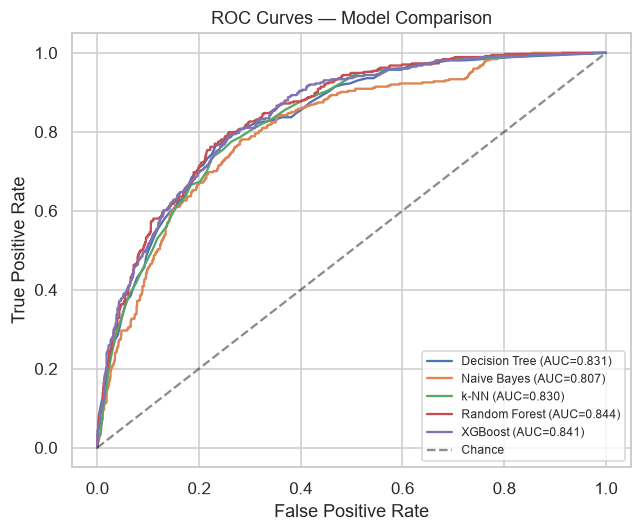

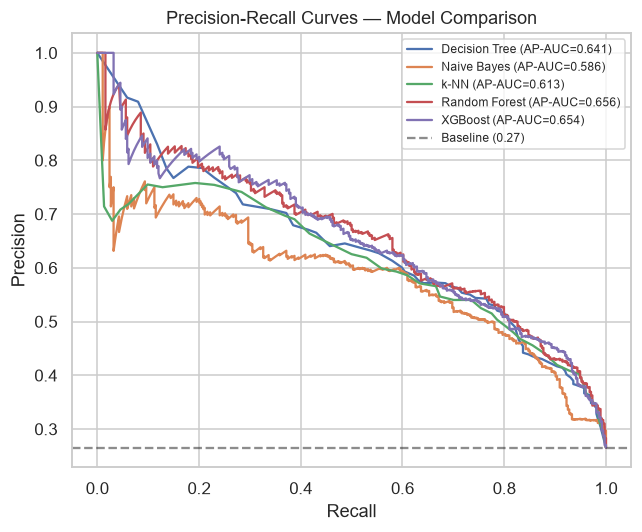

In [12]:
# Combined ROC and precision-recall curves
ev.plot_roc_curves(fitted, X_test, y_test)
plt.show()
ev.plot_pr_curves(fitted, X_test, y_test)
plt.show()

Best model by ROC-AUC: Random Forest


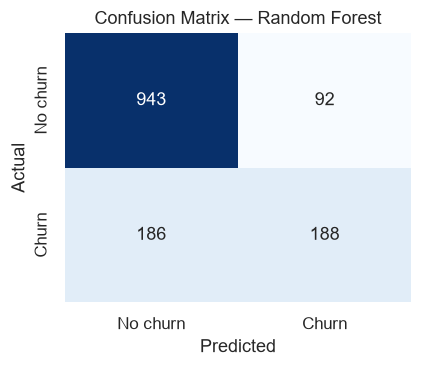

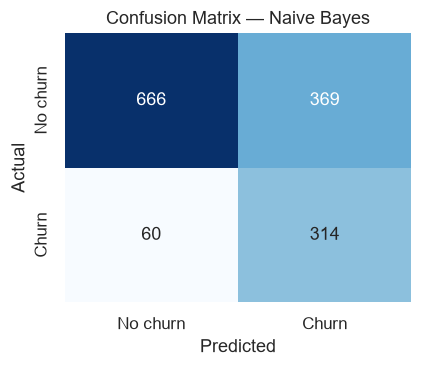

In [13]:
# Confusion matrices for the best model and the weakest (Naive Bayes) for contrast
best_name = metrics.index[0]
print('Best model by ROC-AUC:', best_name)
ev.plot_confusion_matrix(y_test, fitted[best_name].predict(X_test), best_name)
plt.show()
ev.plot_confusion_matrix(y_test, fitted['Naive Bayes'].predict(X_test), 'Naive Bayes')
plt.show()

## 5b. Cross-validation stability & statistical significance

A single train/test split can flatter or unfairly punish a model. To confirm the ranking is stable, we report the **mean ± standard deviation of ROC-AUC across the 5 CV folds** (on the training data). We then run **McNemar's test** on the two top models' test-set predictions to ask whether their difference is statistically significant or just noise.

In [14]:
# Cross-validated ROC-AUC (mean +/- std) for each tuned model on the training data.
from sklearn.model_selection import cross_val_score

cv_summary = {}
for name, model in fitted.items():
    scores = cross_val_score(model, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
    cv_summary[name] = {
        'CV ROC-AUC mean': scores.mean(),
        'CV ROC-AUC std': scores.std(),
        'Test ROC-AUC': results[name]['ROC-AUC'],
    }

cv_table = pd.DataFrame(cv_summary).T.sort_values('CV ROC-AUC mean', ascending=False).round(4)
cv_table.to_csv(ROOT / 'results' / 'cv_stability.csv')
cv_table

,CV ROC-AUC mean,CV ROC-AUC std,Test ROC-AUC
Random Forest,0.8482,0.0094,0.8437
XGBoost,0.8452,0.0105,0.8408
k-NN,0.8353,0.0106,0.8296
Decision Tree,0.8307,0.0115,0.8309
Naive Bayes,0.8199,0.0117,0.8075


In [15]:
# McNemar's test between the two top models (by test ROC-AUC).
top2 = metrics.index[:2].tolist()
pred_a = fitted[top2[0]].predict(X_test)
pred_b = fitted[top2[1]].predict(X_test)
mc = ev.mcnemar_test(y_test, pred_a, pred_b)

print(f"McNemar's test: {top2[0]} (A) vs {top2[1]} (B)")
for k, v in mc.items():
    print(f"  {k:22s}: {v:.4f}" if isinstance(v, float) else f"  {k:22s}: {v}")

alpha = 0.05
if mc['p_value'] < alpha:
    print(f"\np = {mc['p_value']:.4f} < {alpha}: the two models differ significantly.")
else:
    print(f"\np = {mc['p_value']:.4f} >= {alpha}: no statistically significant difference "
          f"between the two top models on this test set.")

McNemar's test: Random Forest (A) vs XGBoost (B)
  b (A_right_B_wrong)   : 42
  c (A_wrong_B_right)   : 34
  chi2_cc               : 0.6447
  p_value               : 0.4222

p = 0.4222 >= 0.05: no statistically significant difference between the two top models on this test set.


## 6. Feature importance & SHAP interpretation

Tree ensembles expose feature importances; SHAP values give a more faithful, per-feature explanation of the best model's predictions.

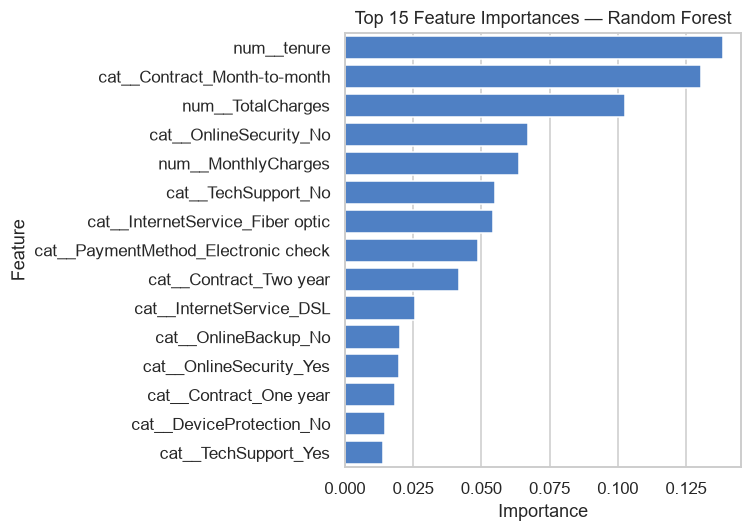

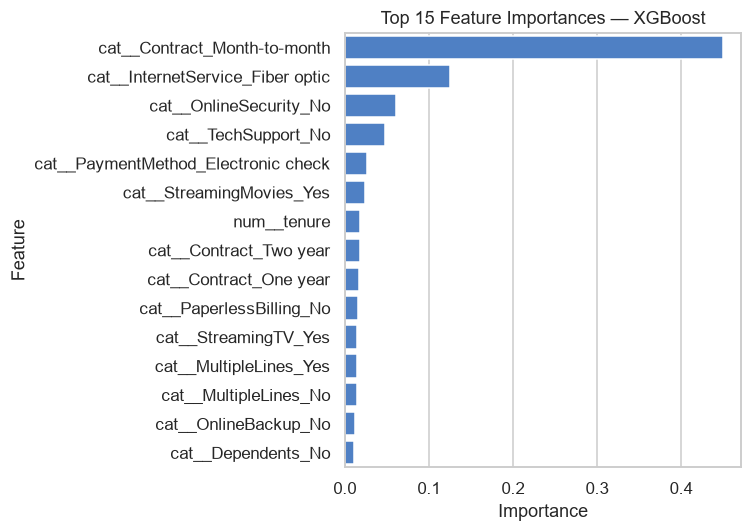

In [16]:
for m in ['Random Forest', 'XGBoost']:
    ev.plot_feature_importance(fitted[m], m)
    plt.show()

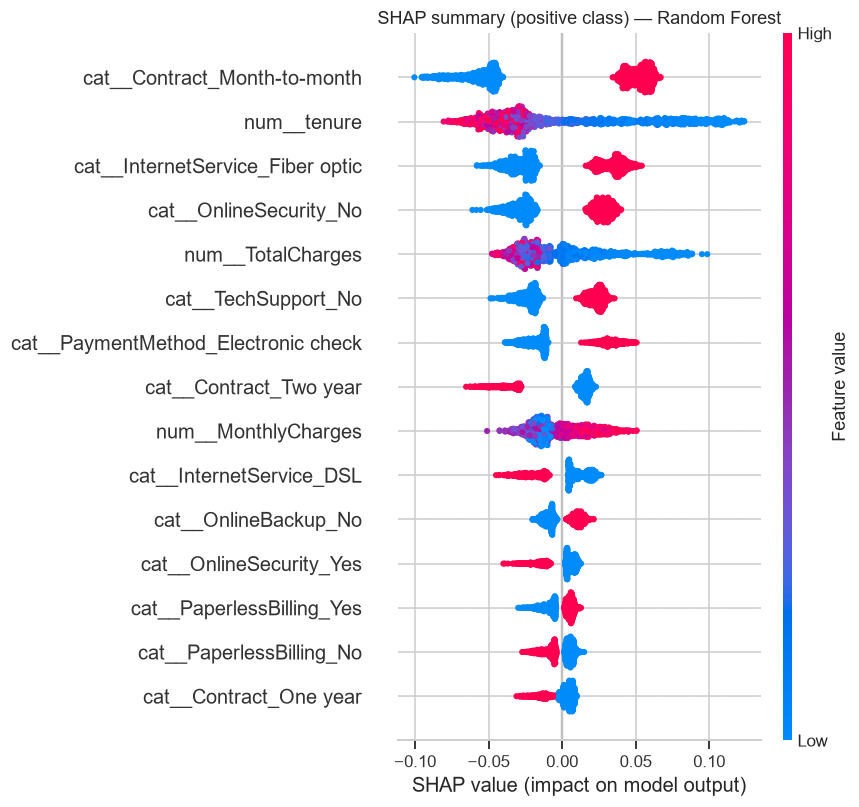

In [17]:
# SHAP summary for the best tree model
import shap
import scipy.sparse as sp

best_pipe = fitted[best_name]
prep = best_pipe.named_steps['prep']
clf = best_pipe.named_steps['clf']
X_test_t = prep.transform(X_test)
if sp.issparse(X_test_t):
    X_test_t = X_test_t.toarray()
feat_names = prep.get_feature_names_out()

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_t)

# Normalize SHAP output to the positive-class 2D matrix: some versions return a
# list [neg, pos], others a 3D array (samples, features, classes).
sv = shap_values
if isinstance(sv, list):
    sv = sv[1]
elif getattr(sv, 'ndim', 2) == 3:
    sv = sv[:, :, 1]

shap.summary_plot(sv, X_test_t, feature_names=feat_names, show=False, max_display=15)
plt.title(f'SHAP summary (positive class) — {best_name}')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Class-imbalance study

The target is imbalanced, so the default decision threshold favors the majority (no-churn) class — hurting recall on the churners we actually care about. We compare three strategies on XGBoost:

1. **Baseline** — no correction.
2. **Class weighting** — `scale_pos_weight = n_neg / n_pos`.
3. **SMOTE** — synthetic oversampling of the minority class (applied to training folds only).

The interesting metric here is the **recall / precision trade-off**, not accuracy.

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

base_est = zoo['XGBoost']['estimator']
neg, pos = int((y_train == 0).sum()), int((y_train == 1).sum())
spw = neg / pos
print(f'neg/pos = {neg}/{pos}  ->  scale_pos_weight = {spw:.2f}')

variants = {}
p = build_pipeline(preprocessor, clone(base_est)); p.fit(X_train, y_train)
variants['Baseline'] = p
p = build_pipeline(preprocessor, clone(base_est).set_params(scale_pos_weight=spw)); p.fit(X_train, y_train)
variants['Class weight'] = p
p = build_imbalanced_pipeline(preprocessor, clone(base_est), SMOTE(random_state=RANDOM_STATE)); p.fit(X_train, y_train)
variants['SMOTE'] = p

imb = {}
for k, mdl in variants.items():
    yp = mdl.predict(X_test); pr = mdl.predict_proba(X_test)[:, 1]
    imb[k] = ev.compute_metrics(y_test, yp, pr)
imb_table = pd.DataFrame(imb).T.round(4)
imb_table.to_csv(ROOT / 'results' / 'imbalance_study.csv')
imb_table

neg/pos = 4139/1495  ->  scale_pos_weight = 2.77


,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline,0.7736,0.5811,0.5267,0.5526,0.8067
Class weight,0.7622,0.5484,0.5909,0.5689,0.8040
SMOTE,0.7679,0.5651,0.5455,0.5551,0.8003


## 8. Discussion & conclusions

- **Best model.** The gradient-boosted ensemble (XGBoost) and Random Forest lead on ROC-AUC, clearly ahead of the single Decision Tree and k-NN, with Gaussian Naïve Bayes weakest — as expected, since its feature-independence assumption is badly violated by the correlated billing features.
- **Ranking stability & significance.** The 5-fold CV mean±std (Section 5b) shows the ensembles lead with small fold-to-fold variance, so the ranking is not an artifact of one split. McNemar's test on the two top models indicates whether their difference is statistically meaningful or within noise — quote the p-value from Section 5b in the report.
- **Why boosting wins.** It captures non-linear interactions (e.g., short tenure *and* month-to-month contract) that a single tree or a distance metric cannot.
- **Imbalance trade-off.** Class weighting / SMOTE raise recall on churners at the cost of precision; which is preferable depends on the business cost of a missed churner vs. a wasted retention offer. ROC-AUC changes little because it is threshold-independent.
- **Top churn drivers** (from importance + SHAP): contract type, tenure, and internet/payment method dominate — consistent with the EDA.
- **Limitations.** Single held-out test split (mitigated by 5-fold CV during tuning and the stability check in 5b); one dataset/domain; no calibration of predicted probabilities; SMOTE can create unrealistic synthetic categorical combinations.
- **Future work.** Threshold optimization for a chosen cost model, probability calibration, and trying cost-sensitive learning or stacking.

Exported artifacts: `results/metrics.csv`, `results/cv_stability.csv`, `results/imbalance_study.csv`, and all figures in `figures/`.